In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [2]:
import os
os.environ["PYKEOPS_VERBOSE"] = "0"
import sys
sys.path.append(os.path.abspath("conditional-flow-matching"))
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from visualize.plots import *

In [3]:
import random
import umap
from models.modules import *
from visualize.plots import *

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
from scripts.run_model import *
from eval.eval import *

In [6]:
%reload_ext autoreload
%autoreload 2

In [7]:
############################################################

In [8]:
def plot_t(traj, legend=True):
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.scatter(
        adata.obsm["X_phate_standardized"][:, 0],
        adata.obsm["X_phate_standardized"][:, 1],
        c=adata.obs["timepoint"].tolist(),
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")

In [9]:
adata = sc.read_h5ad("/home/azweig/projects/zebrafish/data/ebdata_v3.h5ad")
adata

AnnData object with n_obs × n_vars = 18203 × 17789
    obs: 'sample_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden', 'dpt_pseudotime', '1d-phate', '1d-phate-normalized'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_name', 'gene_id', 'gene_name_id'
    uns: 'diffmap_evals', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'sample_labels_colors', 'tsne', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_phate', 'X_phate_normalized', 'X_phate_real_time', 'X_phate_time', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

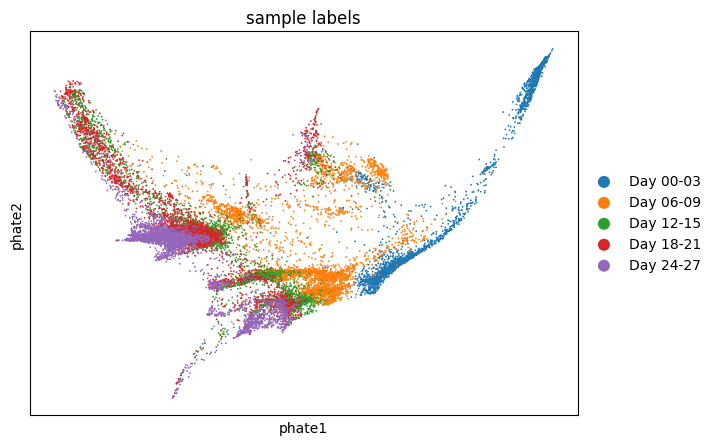

In [10]:
sc.pl.scatter(adata, basis="phate", color="sample_labels")

In [11]:
adata.obs['sample_labels'].value_counts()

sample_labels
Day 06-09    4374
Day 18-21    3873
Day 12-15    3650
Day 24-27    3650
Day 00-03    2656
Name: count, dtype: int64

In [12]:
# n_times = len(adata.obs["sample_labels"].unique())
# Standardize coordinates
coords = adata.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_phate_standardized"] = coords
# X = [
#     adata.obsm["X_phate_standardized"][adata.obs["sample_labels"].cat.codes == t]
#     for t in range(n_times)
# ]

In [13]:
adata.obsm['X_pca'] = adata.obsm["X_phate_standardized"].astype(float)
adata.varm['PCs'] = np.zeros((adata.shape[1], 2)).astype(float)

In [14]:
adata.uns['std'] = np.std(adata.obsm['X_pca'][:,0]) #top pc to std=1
adata_raw = adata.copy()
adata.obsm['X_pca'] /= adata.uns['std']
# adata.uns['std'] = 1.0

In [15]:
energy_only = False

In [17]:
project = "embryoid-metric"

In [18]:
wandb.finish()

In [19]:
label_to_timepoint = {
    'Day 00-03': 1,
    'Day 06-09': 7,
    'Day 12-15': 13,
    'Day 18-21': 19,
    'Day 24-27': 25,
}
T = max(label_to_timepoint.values())
label_to_timepoint = {key: label_to_timepoint[key]/T for key in label_to_timepoint.keys()}

adata.obs['timepoint'] = adata.obs['sample_labels'].map(label_to_timepoint)
adata.obs['gene_target'] = pd.Categorical(["ctrl-inj"] * adata.shape[0])
values = ['ctrl-inj']

In [20]:
conditions, dataset = extract_dataset(adata, values)

In [21]:
pre_score_model, pre_energy_model, score_model, energy_model, embed_model, flow_model = run_full_model(config, project, adata, values, conditions, dataset)

Running phase pre_score:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type | Params | Mode 
-------------------------------------------
0 | score_net | EMA  | 

epoch,▁▁▁▁▁▁▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,▅▅▅█▅▄▄▃▄▆▅▅▃▂▄▂▂▅▄▃▅▅▃▃▅▃▅▃▄█▄▄▅▅▄▂▄▅▄▁
trainer/global_step,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▆▆▆▆▆▆▇▇█████
epoch,499
train_loss,5.3534
trainer/global_step,17999


Running phase pre_energy:.......


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type           | Params | Mode 
------------------------------------------------------
0 | embed_net  | SimpleDenseNet | 225 K  | train
1 | geo_net    | SinNet         | 218 K  | train
2 | energy_net | SimpleDenseNet | 200 K  | eval 
3 | score_net  | EMA            | 401 K  | eval 
------------------------------------------------------
444 K     Trainable params
602 K     Non-trainable params
1.0 M     Total params
4.184     Total estimated model params 

epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇████████
train_loss,█▄▃▃▃▃▂▂▃▂▂▂▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▂▂▂▂▂▂▁▂▂▁▁▂
trainer/global_step,▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇███
epoch,1999
train_loss,144.97482
trainer/global_step,1999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | flow_net  | SinNet         | 217 K  | train
1 | embed_net | SimpleDenseNet | 225 K  | eval 
2 | geo_net   | SinNet         | 218 K  | eval 
3 | score_net | EMA            | 401 K  | eval 
-----------------------------------------------------
435 K     Trainable params
627 K     Non-trainable params
1.1 M     Total params
4.252     Total estimated model params size (M

epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇████
train_loss,█▆▆▇▇▃▅▄▃▃▄▃▃▃▃▂▂▃▃▂▂▂▃▃▃▂▁▂▁▃▂▂▁▂▂▁▁▁▂▁
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▇▇▇█
epoch,1999
train_loss,2.66518
trainer/global_step,1999


In [22]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(score_model)
remove_all_forward_hooks(energy_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

torch.Size([30, 30])
torch.Size([30, 30])
torch.Size([900, 2])


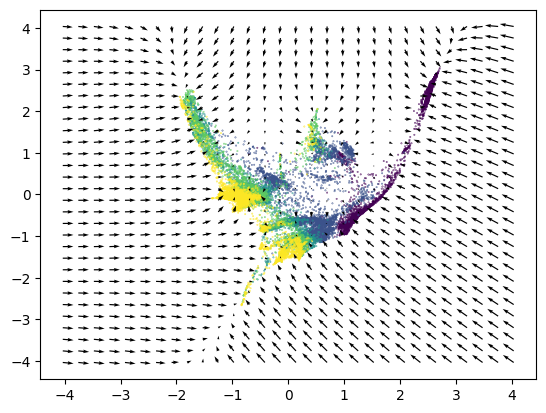

In [23]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()

m = torch.max(torch.abs(samples))
m += 1

xs = torch.linspace(-m, m, steps=30)
ys = torch.linspace(-m, m, steps=30)
x, y = torch.meshgrid(xs, ys, indexing='xy')
print(x.shape)
print(y.shape)
z = torch.stack([x, y], dim = -1).reshape(900, -1)

print(z.shape)

v = score_model(z).detach()

fig, ax = plt.subplots()

ax.scatter(samples[:,0], samples[:, 1], c=adata.obs["timepoint"].tolist(), s=.1)
ax.quiver(z[:,0], z[:,1], v[:,0], v[:,1])
plt.show()

In [24]:
def visualize_energy(energy_model, samples, grid_steps=30, prune=False):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    grid   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    E = energy_model.get_energy(grid).detach().reshape(grid_steps, grid_steps)
    
    if prune:
        E = embed_model.G_interpolate(grid, noise=False).detach().reshape(grid_steps, grid_steps)
        #DEBUG
        # E = G_interpolate_debug(embed_model, grid).detach().reshape(grid_steps, grid_steps)

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.03)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative " + ("energy" if not prune else "metric tensor"))
    plt.show()

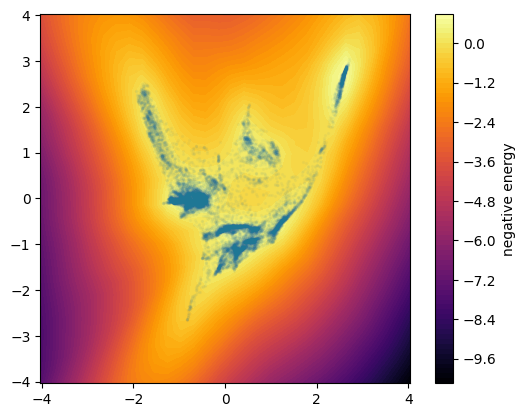

In [25]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(pre_energy_model, samples, prune=False)

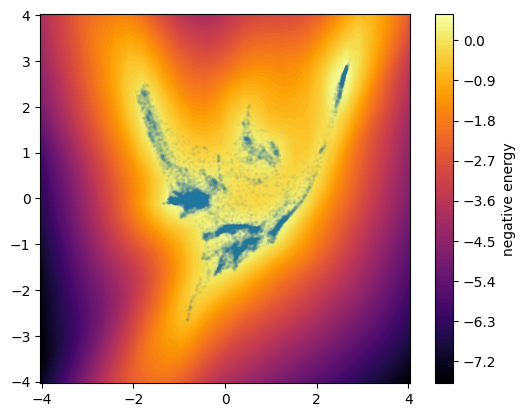

In [26]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(energy_model, samples, prune=False)

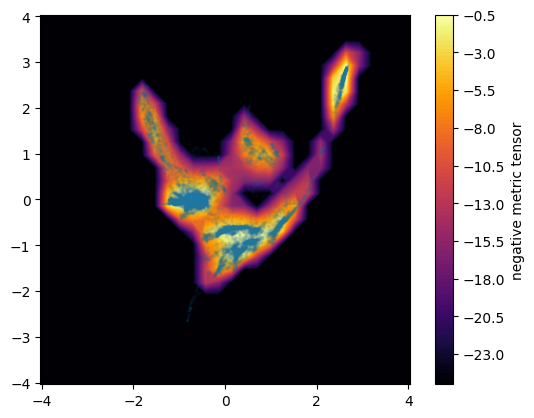

In [27]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(energy_model, samples, prune=True)

In [28]:
value = 'ctrl-inj'
num_traj = 200
timepoints = sorted(label_to_timepoint.values())
t0 = min(timepoints)
t1 = max(timepoints)
    
c = conditions[value]
c = c.unsqueeze(0).repeat(num_traj, 1)

X0 = adata[adata.obs['timepoint'] == t0].obsm['X_pca']

traj = flow_model.sample_traj(X0, c, t0, t1, num_traj, steps=400).detach().cpu().numpy()



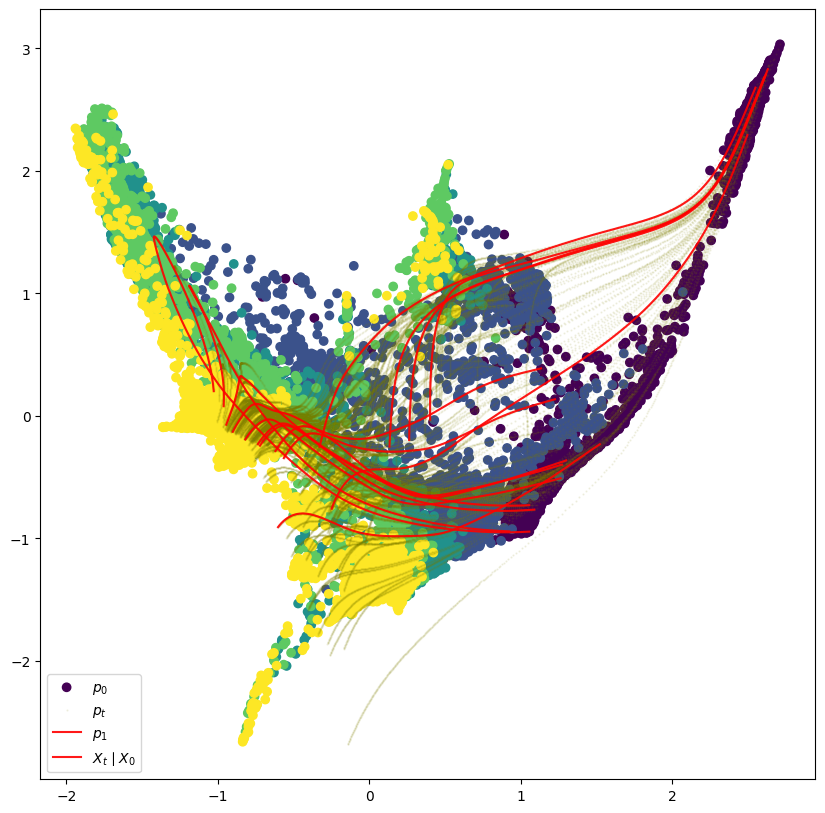

In [29]:
plot_t(traj)